In [1]:
import numpy as np
from scipy.ndimage import uniform_filter

# --- 1️⃣ Original Matrix ---
A = np.array([
    [2, 4, 6, 1, 1],
    [3, 7, 6, 2, 0],
    [4, 7, 2, 5, 4],
    [3, 0, 6, 2, 1],
    [5, 7, 5, 1, 2]
], dtype=float)

kr, kc = 3, 3  # Kernel size

# --- 2️⃣ Apply Harmonic Mean Filter ---
# Convert to float (like im2double in MATLAB)
sg = A.astype(np.float64)

# Apply harmonic mean formula: (kr*kc) / (sum(1/(A+eps)))
eps = 1e-8  # Small constant to avoid divide-by-zero
inv_mean = uniform_filter(1.0 / (sg + eps), size=(kr, kc), mode='nearest')
sf = (kr * kc) / inv_mean

# --- 3️⃣ Display Results ---
print("Original Matrix:")
print(A)

print("\nAfter Harmonic Mean Filter (resultant matrix):")
print(np.round(sf, 3))


Original Matrix:
[[2. 4. 6. 1. 1.]
 [3. 7. 6. 2. 0.]
 [4. 7. 2. 5. 4.]
 [3. 0. 6. 2. 1.]
 [5. 7. 5. 1. 2.]]

After Harmonic Mean Filter (resultant matrix):
[[24.475 32.712 22.235  0.     0.   ]
 [29.974 33.029 26.393  0.     0.   ]
 [ 0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.    18.764 15.577]
 [ 0.     0.     0.    15.987 12.462]]


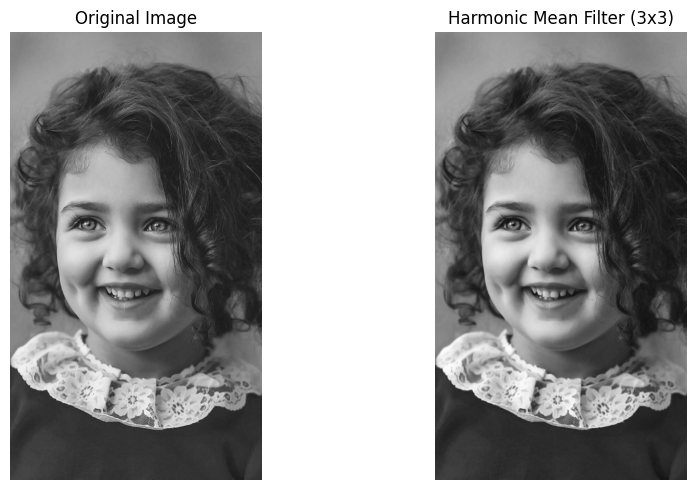

In [6]:
import cv2
import numpy as np
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt

# --- 1️⃣ Read Image ---
# Load the image in grayscale
img = cv2.imread('pk.jpg', cv2.IMREAD_GRAYSCALE)

# Check if the image was loaded correctly
if img is None:
    raise ValueError("Image not found. Please make sure 'pk.jpg' is in the same folder.")

# --- 2️⃣ Define Kernel Size ---
kr, kc = 3, 3   # Window size (3x3)
eps = 1e-8       # Small constant to avoid division by zero

# --- 3️⃣ Apply Harmonic Mean Filter ---
# Formula: H = (kr*kc) / (Σ (1 / (I + ε)))
img_float = img.astype(np.float32) + eps
inv_mean = uniform_filter(1.0 / img_float, size=(kr, kc), mode='nearest')
harmonic_img = (kr * kc) / inv_mean

# Normalize result to 0–255 and convert back to uint8
harmonic_img = cv2.normalize(harmonic_img, None, 0, 255, cv2.NORM_MINMAX)
harmonic_img = np.uint8(harmonic_img)

# --- 4️⃣ Display Results ---
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(harmonic_img, cmap='gray')
plt.title(f'Harmonic Mean Filter ({kr}x{kc})')
plt.axis('off')

plt.tight_layout()
plt.show()
